In [2]:
import pandas as pd
df = pd.read_csv("Electric_vehicle.csv")
df.head()

,vehicle_id,vehicle_type,battery_capacity_kwh,vehicle_model,vehicle_age,motor_power_kw,vehicle_weight_kg,state_of_charge,battery_temperature,battery_voltage,...,road_condition,traffic_level,terrain,wind_speed,ac_usage,passenger_load,headlight_usage,infotainment_usage,energy_consumption_kwh_per_100km,estimated_range_km
0,EV100000,Scooty,5.03,Ather 450X,7.88,3.67,97.8,48.05,39.05,68.33,...,Poor,High,Hilly,17.86,High,1,On,On,8.00,26.43
1,EV100001,Car,28.51,Hyundai Ioniq 5,11.99,42.02,1669.2,41.78,40.57,402.35,...,Good,Medium,Flat,9.78,Medium,4,On,Off,23.43,40.92
2,EV100002,Bus,154.78,Ashok Leyland Switch,5.62,150.21,8231.3,21.43,22.42,696.31,...,Excellent,Medium,Flat,7.70,Low,13,Off,On,132.98,22.61
3,EV100003,Scooty,6.44,Bajaj Chetak,7.01,10.02,111.5,24.78,12.94,46.13,...,Good,High,Flat,13.60,Low,1,Off,On,8.00,17.61
4,EV100004,Car,59.79,BYD Atto 3,5.16,101.76,1897.4,50.13,30.43,394.63,...,Average,Low,Flat,8.34,Off,2,Off,Off,20.12,133.63


In [3]:
df.columns

Index(['vehicle_id', 'vehicle_type', 'battery_capacity_kwh', 'vehicle_model',
       'vehicle_age', 'motor_power_kw', 'vehicle_weight_kg', 'state_of_charge',
       'battery_temperature', 'battery_voltage', 'battery_current',
       'battery_cycles', 'battery_health', 'charging_type', 'charging_time',
       'average_speed', 'maximum_speed', 'acceleration', 'driving_style',
       'distance_travelled', 'regenerative_braking', 'outside_temperature',
       'humidity', 'road_condition', 'traffic_level', 'terrain', 'wind_speed',
       'ac_usage', 'passenger_load', 'headlight_usage', 'infotainment_usage',
       'energy_consumption_kwh_per_100km', 'estimated_range_km'],
      dtype='str')

In [4]:
df.dtypes

vehicle_id                              str
vehicle_type                            str
battery_capacity_kwh                float64
vehicle_model                           str
vehicle_age                         float64
motor_power_kw                      float64
vehicle_weight_kg                   float64
state_of_charge                     float64
battery_temperature                 float64
battery_voltage                     float64
battery_current                     float64
battery_cycles                        int64
battery_health                      float64
charging_type                           str
charging_time                       float64
average_speed                       float64
maximum_speed                       float64
acceleration                        float64
driving_style                           str
distance_travelled                  float64
regenerative_braking                float64
outside_temperature                 float64
humidity                        

In [5]:
df.isnull().sum()

vehicle_id                          0
vehicle_type                        0
battery_capacity_kwh                0
vehicle_model                       0
vehicle_age                         0
motor_power_kw                      0
vehicle_weight_kg                   0
state_of_charge                     0
battery_temperature                 0
battery_voltage                     0
battery_current                     0
battery_cycles                      0
battery_health                      0
charging_type                       0
charging_time                       0
average_speed                       0
maximum_speed                       0
acceleration                        0
driving_style                       0
distance_travelled                  0
regenerative_braking                0
outside_temperature                 0
humidity                            0
road_condition                      0
traffic_level                       0
terrain                             0
wind_speed  

In [6]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
29995    False
29996    False
29997    False
29998    False
29999    False
Length: 30000, dtype: bool

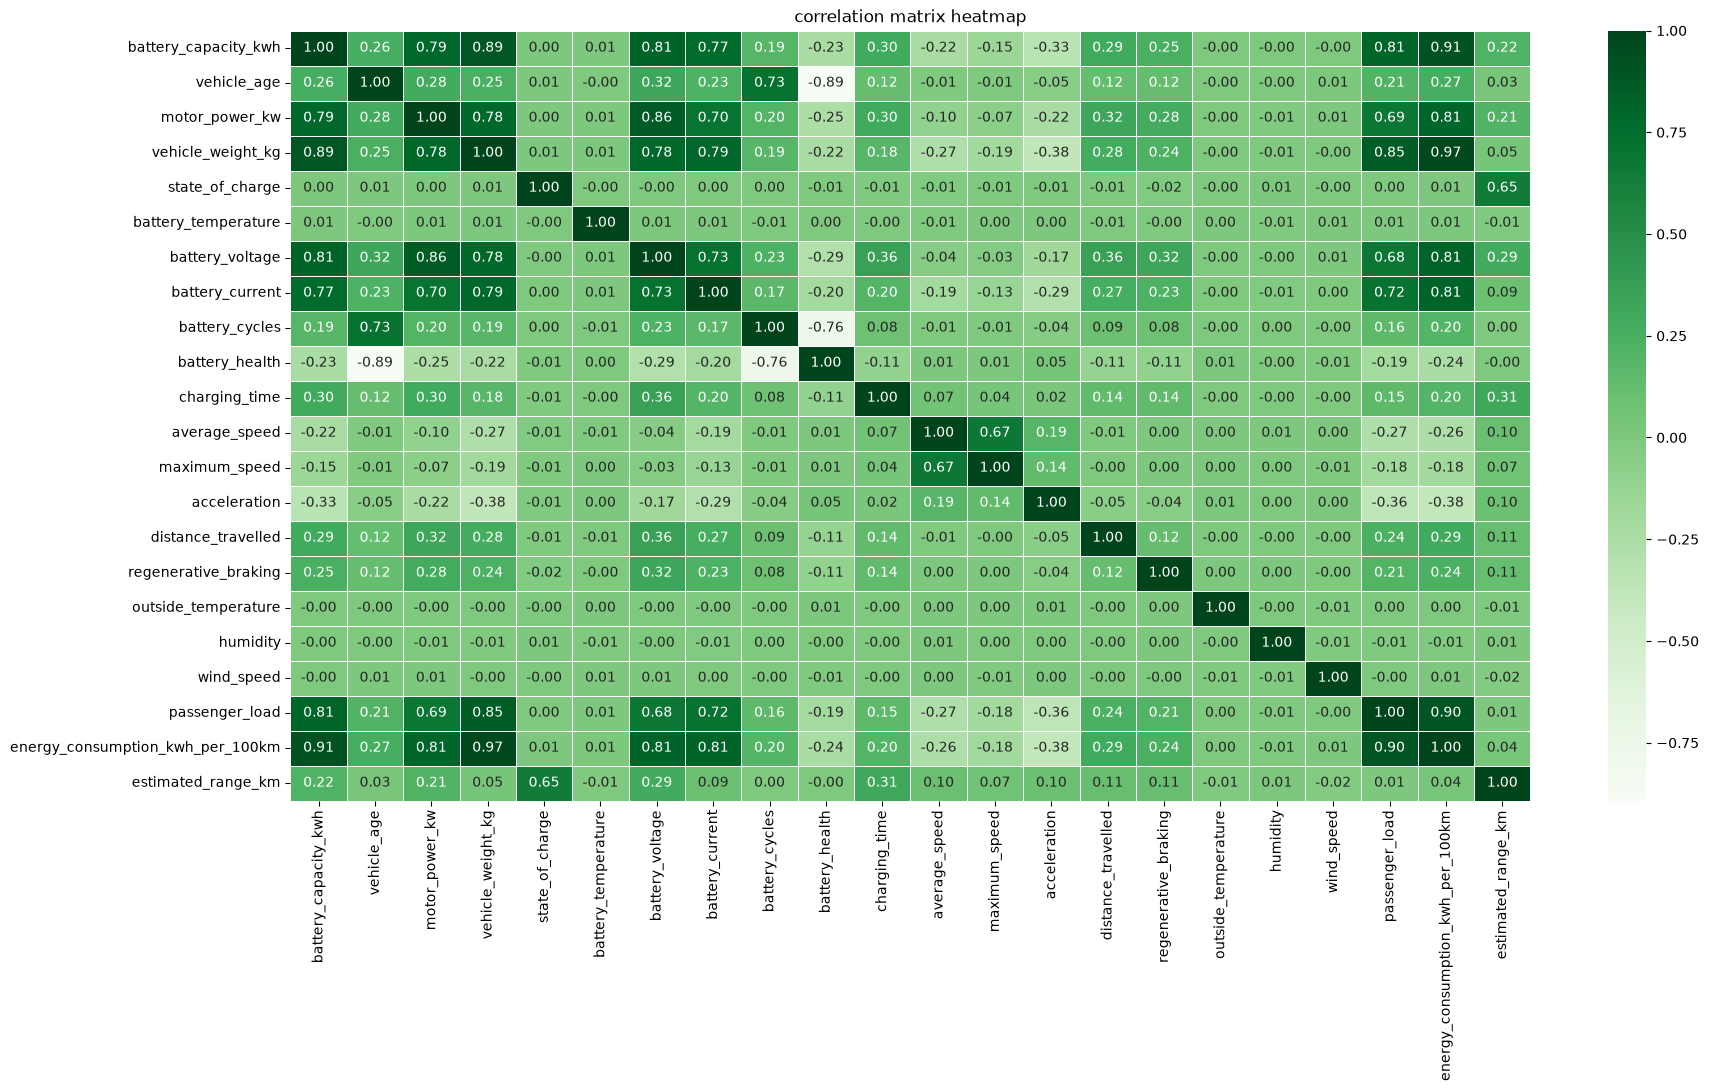

In [8]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(20,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix heatmap")
plt.show()

In [9]:
q1 = df["energy_consumption_kwh_per_100km"].quantile(0.25)
q3 = df["energy_consumption_kwh_per_100km"].quantile(0.75)

IQR = q3 - q1

lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("q1:", q1)
print("q3:", q3)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
outliers = df[
    (df["energy_consumption_kwh_per_100km"] < lower_limit) |
    (df["energy_consumption_kwh_per_100km"] > upper_limit)
]

print("\nenergy_consumption_kwh_per_100km Outliers:",len(outliers))
print("\nenergy_consumption_kwh_per_100km Outliers Data:\n")
print(outliers[[ "vehicle_id", "energy_consumption_kwh_per_100km"]].head(20))

q1: 16.7875
q3: 27.72
Lower Limit: 0.38875000000000526
Upper Limit: 44.11874999999999

energy_consumption_kwh_per_100km Outliers: 4437

energy_consumption_kwh_per_100km Outliers Data:

    vehicle_id  energy_consumption_kwh_per_100km
2     EV100002                            132.98
5     EV100005                            120.78
11    EV100011                            137.81
22    EV100022                            125.12
23    EV100023                            128.71
31    EV100031                            117.71
72    EV100072                            147.74
99    EV100099                            132.73
100   EV100100                            121.33
103   EV100103                            115.64
109   EV100109                            128.37
115   EV100115                            144.51
131   EV100131                            124.22
136   EV100136                            130.64
142   EV100142                            123.80
151   EV100151                 

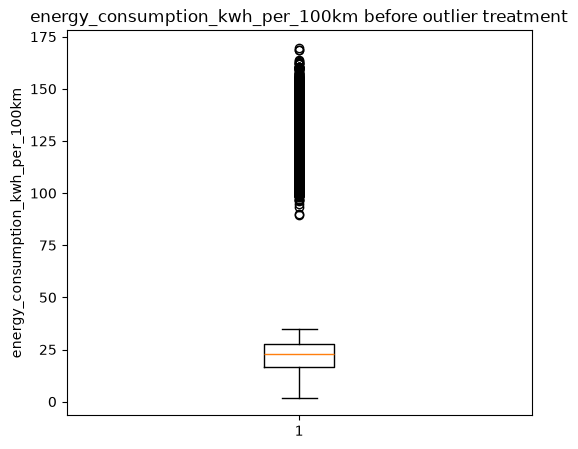

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.boxplot(df["energy_consumption_kwh_per_100km"])
plt.title("energy_consumption_kwh_per_100km before outlier treatment")
plt.ylabel('energy_consumption_kwh_per_100km')
plt.show()

In [11]:
df['energy_consumption_updated'] = df['energy_consumption_kwh_per_100km'].clip(
    lower=lower_limit,
    upper=upper_limit)

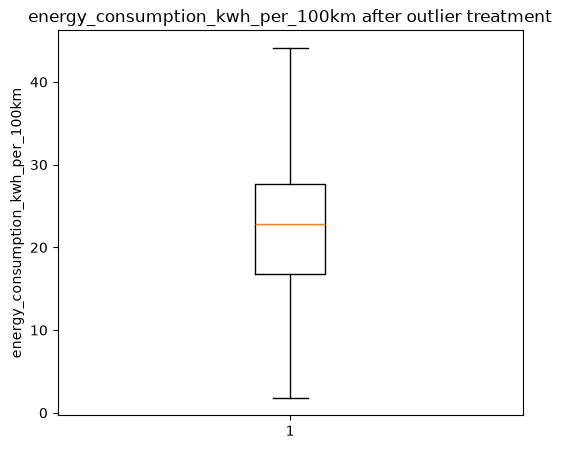

In [12]:
plt.figure(figsize=(6,5))
plt.boxplot(df["energy_consumption_updated"])
plt.title("energy_consumption_kwh_per_100km after outlier treatment")
plt.ylabel('energy_consumption_kwh_per_100km')
plt.show()

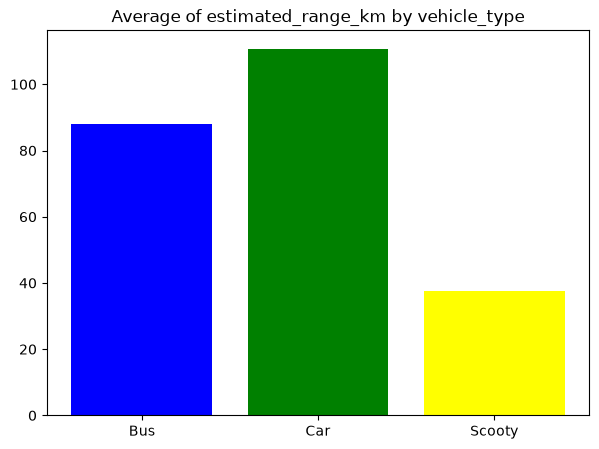

In [15]:
import matplotlib.pyplot as plt
avg_estimated_range_km = df.groupby("vehicle_type")['estimated_range_km'].mean()
plt.figure(figsize=(7,5))
plt.bar(avg_estimated_range_km.index,avg_estimated_range_km.values,color=["blue","green","yellow"])
plt.title("Average of estimated_range_km by vehicle_type")
plt.xlabel = ("vehicle_type")
plt.ylabel = ("Average estimated_range_km")
plt.show()



Average battery health by vehicle type:
vehicle_type
Bus       87.431472
Car       89.740685
Scooty    92.443778
Name: battery_health, dtype: float64


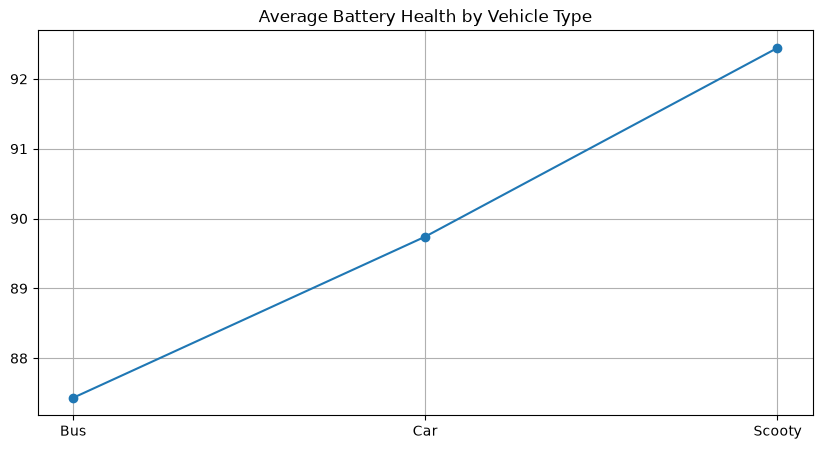

In [18]:
import matplotlib.pyplot as plt
health_by_type = df.groupby("vehicle_type")["battery_health"].mean()

print("\nAverage battery health by vehicle type:")
print(health_by_type)

plt.figure(figsize=(10, 5))

plt.plot(
    health_by_type.index,
    health_by_type.values,
    marker="o"
)

plt.title("Average Battery Health by Vehicle Type")
plt.xlabel = ("Vehicle Type")
plt.ylabel = ("Average Battery Health (%)")
plt.grid(True)

plt.show()


Battery Health and Estimated Range:
   battery_health  estimated_range_km
0           87.54               26.43
1           80.48               40.92
2           90.64               22.61
3           88.30               17.61
4           89.72              133.63
5           86.26               81.61
6           90.42               58.97
7           95.62               30.63
8           88.65               79.62
9           95.10               66.32


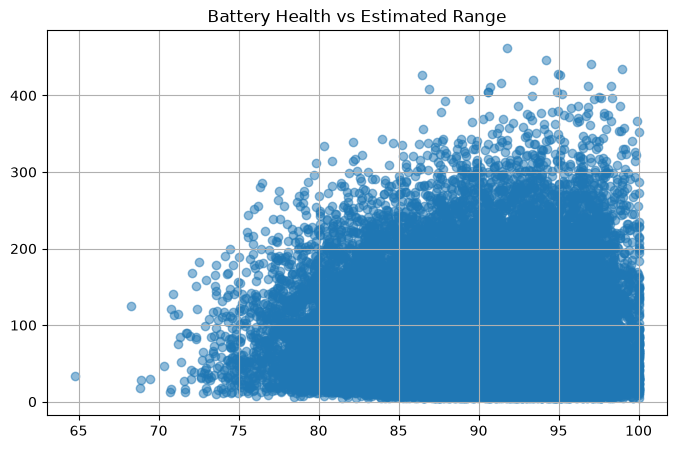

In [20]:
import matplotlib.pyplot as plt
print("\nBattery Health and Estimated Range:")
print(df[["battery_health", "estimated_range_km"]].head(10))

plt.figure(figsize=(8, 5))

plt.scatter(
    df["battery_health"],
    df["estimated_range_km"],
    alpha=0.5
)

plt.title("Battery Health vs Estimated Range")
plt.xlabel = ("Battery Health (%)")
plt.ylabel = ("Estimated Range (km)")
plt.grid(True)

plt.show()


Vehicle Type Distribution:
vehicle_type
Car       18494
Scooty     7069
Bus        4437
Name: count, dtype: int64


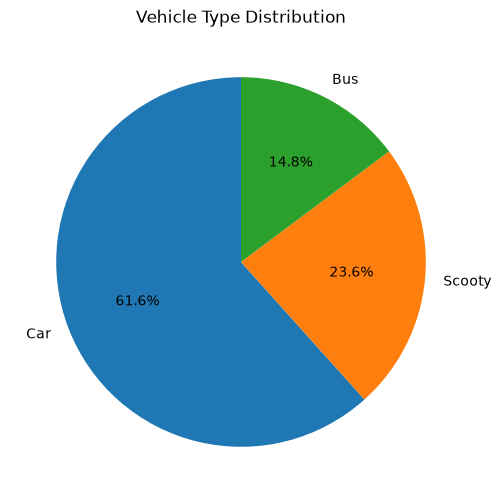

In [ ]:
import matplotlib.pyplot as plt
vehicle_counts = df["vehicle_type"].value_counts()

print("\nVehicle Type Distribution:")
print(vehicle_counts)

plt.figure(figsize=(8, 6))

plt.pie(
    vehicle_counts.values,
    labels=vehicle_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Vehicle Type Distribution")

plt.show()

First 5 Rows:
  vehicle_id vehicle_type  battery_capacity_kwh         vehicle_model  \
0   EV100000       Scooty                  5.03            Ather 450X   
1   EV100001          Car                 28.51       Hyundai Ioniq 5   
2   EV100002          Bus                154.78  Ashok Leyland Switch   
3   EV100003       Scooty                  6.44          Bajaj Chetak   
4   EV100004          Car                 59.79            BYD Atto 3   

   vehicle_age  motor_power_kw  vehicle_weight_kg  state_of_charge  \
0         7.88            3.67               97.8            48.05   
1        11.99           42.02             1669.2            41.78   
2         5.62          150.21             8231.3            21.43   
3         7.01           10.02              111.5            24.78   
4         5.16          101.76             1897.4            50.13   

   battery_temperature  battery_voltage  ...  traffic_level  terrain  \
0                39.05            68.33  ...          

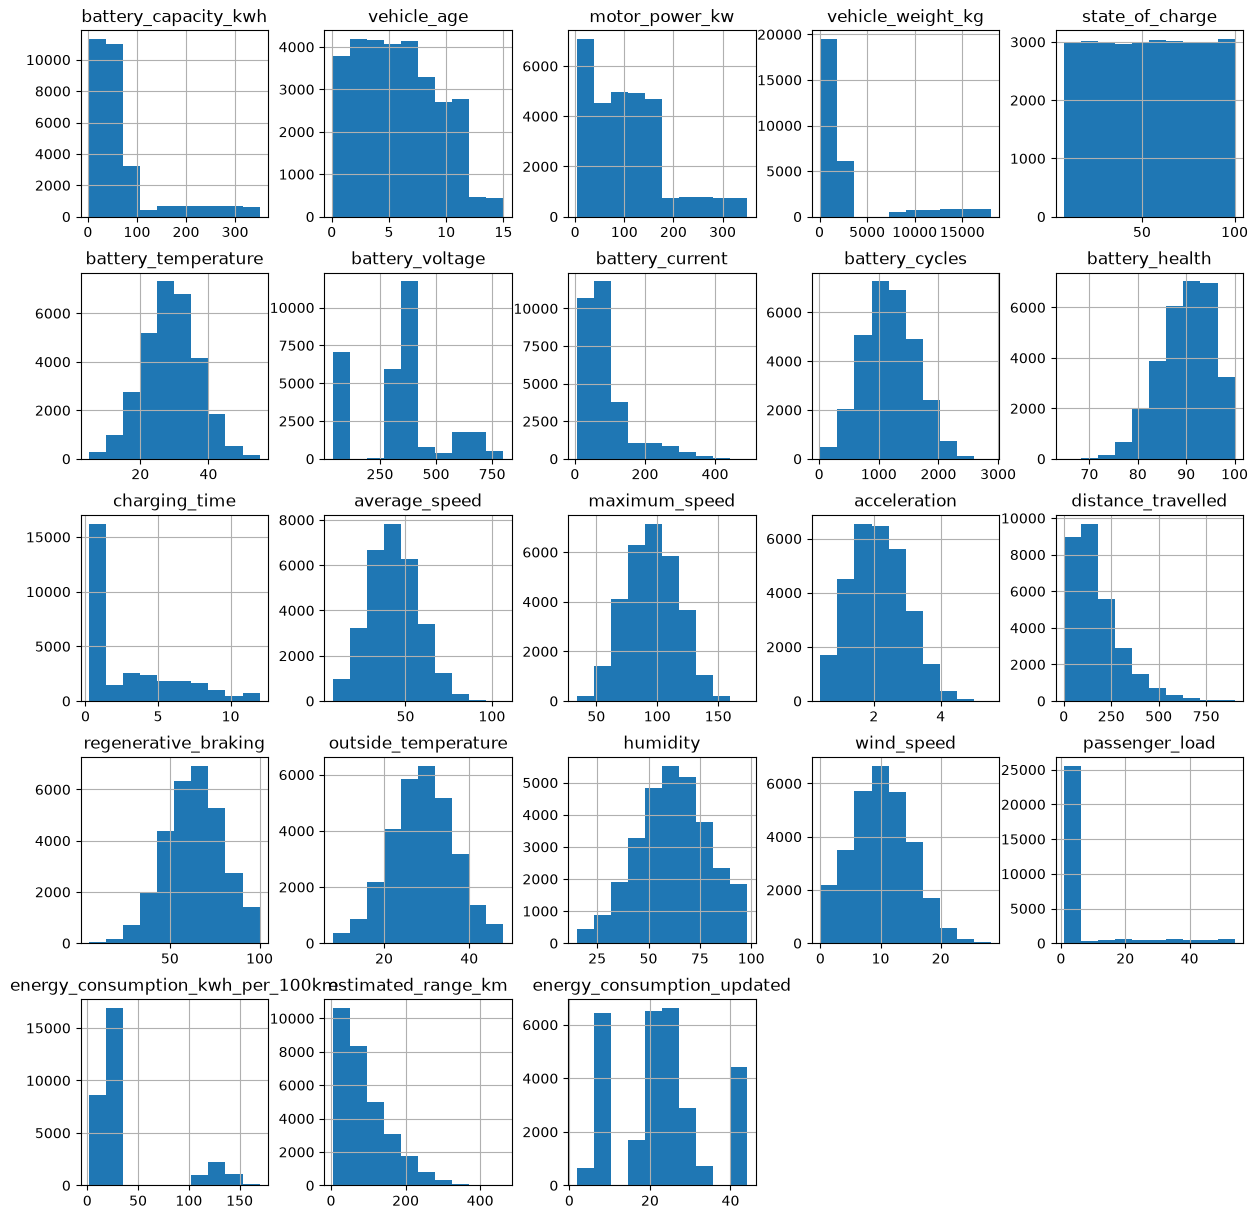

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nShape of Dataset:")
print(df.shape)
df.hist(figsize=(15,15))
plt.title = ("Feature Distributions")
plt.show()